In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [14]:
# Settings 
N: int = 64

DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))
J: float = 1.
H: float = 1.
mu: float = 1.
kB: float = 1.
T: float = 1.


In [4]:
# Functions

def GetDeltaEnergy(i: int, j: int) -> float:
    """Computes the change in energy of altering a single spin state in S at location (x, y)."""
    SC: float = 0.

    for k in DIRS:
        di: int = i + k[0]
        dj: int = j + k[1]

        # Periodic boundaries
        if di >= N:
            di -= N
        if dj >= N:
            dj -= N

        SC += S[i, j] * S[di, dj]

    return 2 * J * SC + 2 * mu * H * S[i, j]


def GetTotalEnergy() -> float:
    """Computes the total energy of a grid of spin states S according to the ising model."""
    energy: float = 0.

    for i in range(N):
        for j in range(N):
            SC: float = 0.

            for k in DIRS:
                di: int = i + k[0]
                dj: int = j + k[1]

                # Periodic boundaries
                if di >= N:
                    di -= N
                if dj >= N:
                    dj -= N

                SC += S[i, j] * S[di, dj]

            energy += -0.5 * J * SC - mu * H * S[i, j]

    return energy


def GetMagnetisation() -> float:
    """Computes the total magnetisation."""
    return mu * S.sum()


def FlipState(i, j) -> None:
    """Flips the spin state at a randomized site."""
    S[i, j] = -1 * S[i, j]


def PlotState() -> None:
    """Plots the spin states of the magnetic substance."""
    plt.imshow(S)
    plt.show()


def Main(tMax: int, plot_4d=False) -> None:
    """Main loop for the metropolis algorithm."""
    flip_counter = np.zeros(tMax)
    for t in range(tMax):
        x, y = np.random.randint(0, N), np.random.randint(0, N)
        dE: float = GetDeltaEnergy(x, y)

        a: float = np.random.rand()
        w: float = min(1, np.exp(-dE / (kB * T)))

        if a <= w:
            FlipState(x, y)
            flip_counter[t]=1
        else:
            continue
    if plot_4d:
        plt.plot(np.cumsum(flip_counter))

    return S, flip_counter

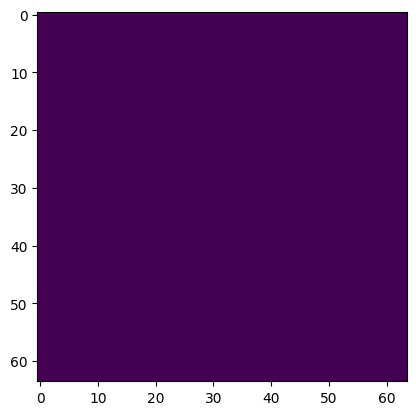

In [5]:
# Results
Main(5_000)
PlotState()

#### Exercise C

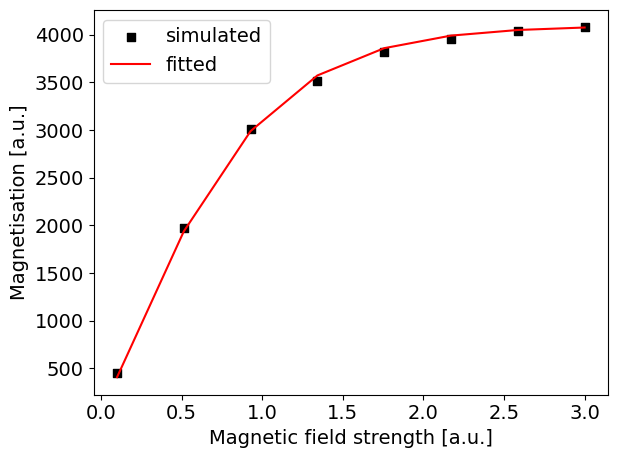

In [6]:
# Exercise C.

# Settings: repeat to reset
N: int = 64

DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))
mu: float = 1.
kB: float = 1.
T: float = 1.

# Specific for c:
J = 0.
Q: int = 8  # number of measurements
hArray: np.ndarray = np.linspace(0.1, 3.0, Q)
mArray: np.ndarray = np.zeros(Q)

for i in range(Q):
    H: float = hArray[i]

    Main(10_000)
    mArray[i] = GetMagnetisation()

mFit: np.ndarray = mu * N * N * np.tanh(mu * hArray / (kB * T))

# mFit: np.ndarray = mu * N * N * (1-np.sinh(2*J/(kB*T))**(-4))**(1/8)


plt.rcParams.update({'font.size': 14})
plt.scatter(hArray, mArray, c='k', marker='s', label='simulated')
plt.plot(hArray, mFit, c='r', label='fitted')
plt.xlabel('Magnetic field strength [a.u.]')
plt.ylabel('Magnetisation [a.u.]')
plt.legend()
plt.tight_layout()
plt.show()


#### Exercise D

0.8434652400403522 -817.0683568903947


(0.0, 12901.35)

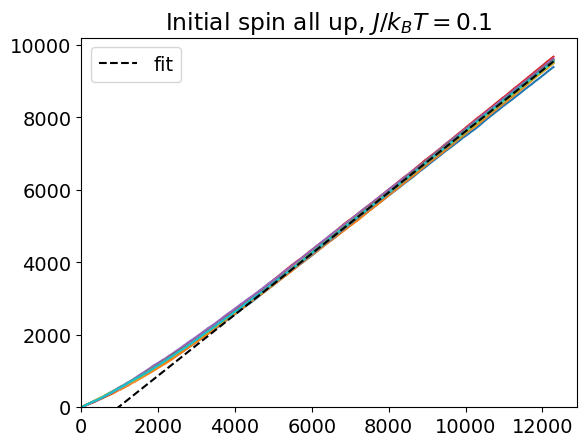

In [7]:
# 4d

# linear fit for equilibrated regime
def line(x, A, B):
    return A*x+B

def fitting(xlist, ycumsum):
    parameters, covariance = curve_fit(f=line, xdata=xlist, ydata=ycumsum)
    return parameters

# updated settings
N: int = 64

DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))
J: float = 0.1
H: float = 0.
mu: float = 1.
kB: float = 1.
T: float = 1.

# measurement settings
tMax = N*N*3
measurements = 10
xdata = np.array(range(tMax))

found_A = np.zeros(measurements)
found_B = np.zeros(measurements)

for i in range(measurements):
    S: np.ndarray = np.ones((N, N))

    _, flip_counter = Main(tMax)

    ycumsum = np.cumsum(flip_counter)

    fit = fitting(xdata[tMax-5000:], ycumsum[tMax-5000:])
    found_A[i] = fit[0]
    found_B[i] = fit[1]


# Visualization
    plt.plot(xdata, ycumsum)

A_avg = np.average(found_A)
B_avg = np.average(found_B)  
print(A_avg, B_avg)  
yfit = line(xdata, A_avg, B_avg)

plt.plot(xdata, yfit, color='black', linestyle='--', label='fit')
plt.legend()
plt.title('Initial spin all up, $J/k_BT=0.1$')
plt.ylim(bottom=0)
plt.xlim(left=0)

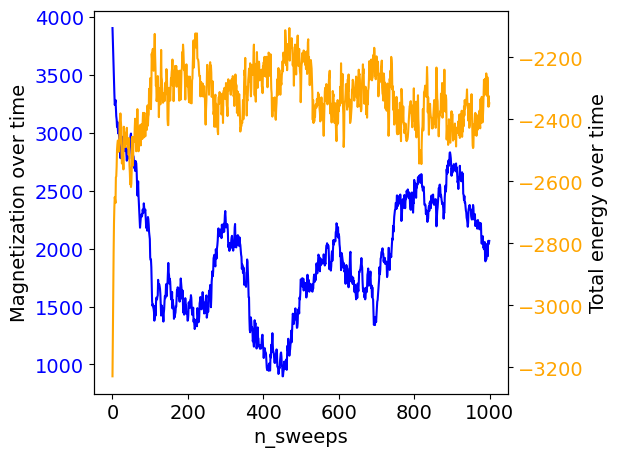

In [ ]:
# updated settings
N: int = 64

DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))          # spin up
# S = np.random.choice([-1,1], size=(N,N)) # random spin
J: float = 0.43
H: float = 0.
mu: float = 1.
kB: float = 1.
T: float = 1.

# measurement settings
n_sweeps=
tMax = N*N*n_sweeps
measurements = 10

m = np.zeros(n_sweeps)
e = np.zeros(n_sweeps)

for t in range(n_sweeps):
    Main(N*N)

    m[t] = GetMagnetisation()
    e[t] = GetTotalEnergy()


fig, ax1 = plt.subplots()

# color = 'tab:red'
ax1.set_xlabel('n_sweeps')
ax1.set_ylabel('Magnetization over time')
ax1.plot(m, 'blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Total energy over time')
ax2.plot(e, 'orange')
ax2.tick_params(axis='y', labelcolor='orange')

fig.tight_layout() 
plt.show()



#### Exercise 4e

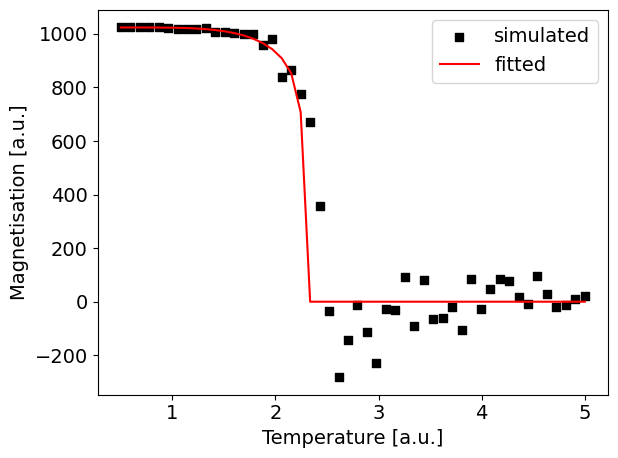

In [17]:
# 4e: adapted from 4c

# Exercise E.

# Settings: repeat to reset
N: int = 32

DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))
J: float = 1.
mu: float = 1.
kB: float = 1.


H = 0
Q: int = 50  # number of measurements

tArray: np.ndarray = np.linspace(0.5, 5.0, Q)
mArray: np.ndarray = np.zeros(Q)

equilibrationSteps = 100*N*N
measurementSteps = 5*N*N

for i in range(Q):
    T = tArray[i]

    S[:] = 1 # to start with all spin up
    Main(equilibrationSteps) # 3 sweeps to equilibrate the system
    Main(measurementSteps) # 

    mArray[i] = GetMagnetisation()

# analytical solution:
T_crit = 2.269 * J / kB
mFit = np.zeros(Q)

belowTc = tArray < T_crit

mFit[belowTc] = mu * N * N * (1-np.sinh(2*J/(kB*tArray[belowTc]))**(-4))**(1/8)


plt.rcParams.update({'font.size': 14})
plt.scatter(tArray, mArray, c='k', marker='s', label='simulated')
plt.plot(tArray, mFit, c='r', label='fitted')
plt.xlabel('Temperature [a.u.]')
plt.ylabel('Magnetisation [a.u.]')
plt.legend()
plt.tight_layout()
plt.show()

#### Exercise 4f

In [27]:
# 4f: adapted from 4e

# Exercise F.

# Additional helper function
def GetSusceptibility(mMeasurements):
    """Calculate magnetic susceptibility from measured magnetisations."""
    return np.var(mMeasurements) / (N * N)

# Settings: repeat to reset
DIRS: np.ndarray = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
S: np.ndarray = np.ones((N, N))

J: float = 1.
mu: float = 1.
kB: float = 1.
T: float = 1.
H: float = 0.

Q: int = 50  # number of measurements

# J/(kB*T) = 0.1 and 0.43
jValues = [0.1, 0.43]

systemSizes = np.array([16, 64, 144, 256, 400, 576, 900, 1156, 1600])
#                       04, 08, 012, 016, 020, 024, 030, 0034, 0040
sideLengths = np.sqrt(systemSizes).astype(int)

chiArray = np.zeros((len(jValues), len(systemSizes)))

equilibrationSweeps = 1000
measurementSweeps = 1000
sweepsBetweenMeasurements = 5

for k in range(len(jValues)):

    J = jValues[k]

    for i in range(len(systemSizes)):
        
        N = sideLengths[i]
        S = np.ones((N, N))

        print(f'J = {J}, N = {N}')

        # Equilibrate
        Main(equilibrationSweeps*N*N)

        mMeasurements = np.zeros(measurementSweeps)

        for j in range(measurementSweeps):
            Main(sweepsBetweenMeasurements*N*N)
            mMeasurements[j] = GetMagnetisation()

        # <M>
        meanM = np.mean(mMeasurements)

        # <(delta M)^2>
        meanDeltaMSquared = np.mean((mMeasurements - meanM)**2)

        # chi = <(delta M)^2> / number of spins
        chiArray[k, i] = meanDeltaMSquared / systemSizes[i]

J = 0.1, N = 4
J = 0.1, N = 8
J = 0.1, N = 12
J = 0.1, N = 16
J = 0.1, N = 20
J = 0.1, N = 24
J = 0.1, N = 30
J = 0.1, N = 34
J = 0.1, N = 40
J = 0.43, N = 4
J = 0.43, N = 8
J = 0.43, N = 12
J = 0.43, N = 16
J = 0.43, N = 20
J = 0.43, N = 24
J = 0.43, N = 30
J = 0.43, N = 34
J = 0.43, N = 40


In [28]:
print(chiArray)
print(chiArray[0])

[[  1.560599     1.54443775   1.52717678   1.62039194   1.50000559
    1.53945805   1.6428846    1.45936539   1.66568694]
 [ 11.845164    37.179226    71.529284    78.04140586 127.451555
   99.26692775 314.36111956 270.25924594 189.8621727 ]]
[1.560599   1.54443775 1.52717678 1.62039194 1.50000559 1.53945805
 1.6428846  1.45936539 1.66568694]


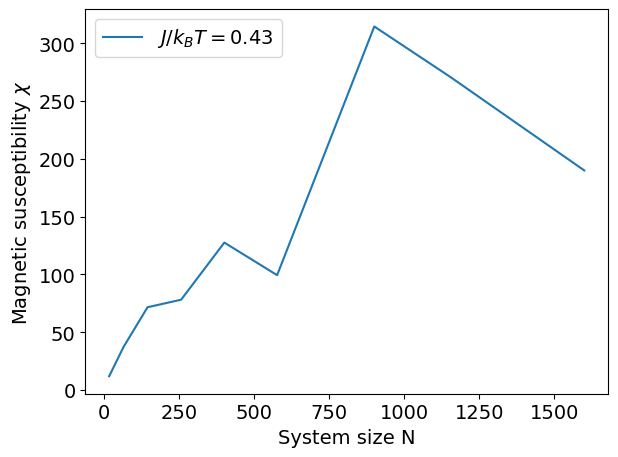

In [ ]:
plt.rcParams.update({'font.size': 14})

plt.plot(systemSizes, chiArray[0], label=r'$J/k_BT = 0.1$')
plt.plot(systemSizes, chiArray[1], label=r'$J/k_BT = 0.43$')

plt.xlabel('System size N')
plt.ylabel(r'Magnetic susceptibility $\chi$')
plt.legend()
plt.tight_layout()
plt.show()

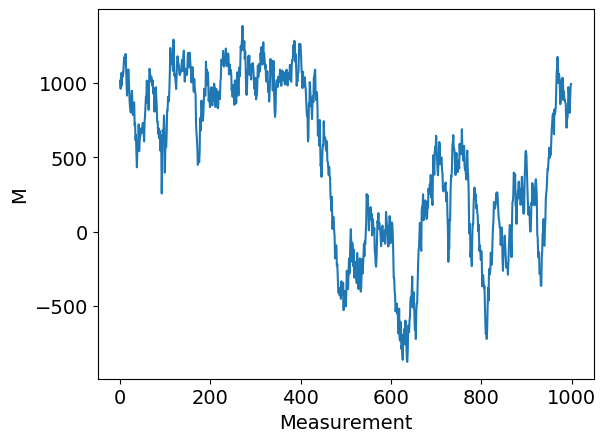

In [31]:
plt.plot(mMeasurements)
plt.xlabel('Measurement')
plt.ylabel('M')
plt.show()